# 제조 시계열 특성을 활용한 불량 예측 비교

**질문:** 현재 공정값에 이전 관측 기록의 변화 정보를 추가하면 미탐과 검사 부담이 개선되는가?

기존 분석의 후속 **탐색 실험**이다. 기존 평가 결과를 이미 확인했으므로 새로운 독립 최종 시험으로 표현하지 않는다. 동일한 랜덤포레스트로 현재 공정값만 사용하는 방식과 과거 변화도 사용하는 방식을 비교한다. 성능 향상을 전제로 하지 않는다.

코랩/캐글 CPU에서 순서대로 실행한다. `labeled_data.csv`만 필요하다. Drive 사용 시 먼저 `from google.colab import drive; drive.mount('/content/drive')`를 실행한 후 아래 DATA_PATH를 따옴표로 감싼 경로로 지정한다. 로컬 CPU 실행 결과가 저장되어 있으며 클라우드 환경 자체를 원격 검증한 것은 아니다.

파일의 일부 라벨 기록만 이용하므로 5건은 5분을 뜻하지 않는다. 연속 전체 생산 흐름·빅데이터 처리 시스템을 구현한 실험이 아니다.

In [1]:
# 일반적인 코랩/캐글 환경에는 아래 패키지가 준비되어 있다.
# import 오류가 있는 경우에만 다음 줄의 주석을 해제해 실행한다.
# %pip install pandas numpy scikit-learn matplotlib
from pathlib import Path
import os, sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance

SEED = 42
INSPECTION_BUDGET = 0.10  # 검증 데이터의 10% 이내. 현장 요구가 아닌 분석용 가정.
DATA_PATH = None  # 예: '/content/labeled_data.csv'
if DATA_PATH is None:
    candidates = [Path('labeled_data.csv'), Path('dataset/labeled_data.csv'),
                  Path('/content/labeled_data.csv')]
    if os.environ.get('MOLDING_DATA_PATH'):
        candidates.insert(0, Path(os.environ['MOLDING_DATA_PATH']))
    if Path('/kaggle/input').exists():
        candidates.extend(Path('/kaggle/input').rglob('labeled_data.csv'))
    existing = list(dict.fromkeys(p.resolve() for p in candidates if p.is_file()))
    if len(existing) == 1:
        DATA_PATH = existing[0]
    elif len(existing) > 1:
        raise ValueError('동명 파일이 여러 개입니다. DATA_PATH를 직접 지정하세요.')
    elif 'google.colab' in sys.modules:
        from google.colab import files
        uploaded = files.upload()
        if 'labeled_data.csv' not in uploaded:
            raise ValueError('labeled_data.csv를 업로드하세요.')
        DATA_PATH = Path('labeled_data.csv')
    else:
        raise FileNotFoundError('labeled_data.csv를 연결하고 DATA_PATH를 지정하세요.')
DATA_PATH = Path(DATA_PATH)
raw = pd.read_csv(DATA_PATH, dtype={'PART_FACT_SERIAL': str})
print('Python:', platform.python_version(), 'pandas:', pd.__version__, 'sklearn:', sklearn.__version__)
print('파일:', DATA_PATH.name, '행/열:', raw.shape)
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('SHA256:', source_sha256)
display(raw[['TimeStamp','PART_NAME','PassOrFail','Injection_Time','Max_Injection_Pressure']].head())

Python: 3.12.14 pandas: 3.0.5 sklearn: 1.9.0
파일: labeled_data.csv 행/열: (7996, 45)
SHA256: e8d375c8e0c2cdfc309baf01ac2203fc2edb6e9728e836119042f9670cd46b51


,TimeStamp,PART_NAME,PassOrFail,Injection_Time,Max_Injection_Pressure
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,Y,9.60,141.800003
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,Y,9.60,141.800003
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,Y,9.59,141.800003
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003


## 1. 시간 구조와 이력 구간

완전 중복을 제거하고 S14의 CN7/RG3만 남긴다. 원본 Y/N을 불량 1/양품 0으로 매핑한다. 시간과 ID로 정렬한다.

같은 설비·제품 안에서도 **날짜, 생산 지시일/코드가 바뀌거나 관측 간격이 30분을 넘으면** 새 이력 구간으로 시작한다. 30분은 전체 기록의 통상 간격(약 60초)보다 충분히 긴 공백을 구분하기 위한 사전 분석 가정이며, 실제 공장 가동·정지 기준이 아니다. 성능 점수에 맞춰 조정하지 않는다. 제품별로 구분하므로 다른 제품의 값은 이력에 섞지 않는다.

원본/분석 행: 7996 5230 불량: 60 이력 구간: 33


,gap_seconds
count,5.226000e+03
mean,1.117077e+03
std,2.509335e+04
min,3.000000e+00
50%,6.000000e+01
90%,6.200000e+01
95%,6.300000e+01
99%,1.240000e+02
max,1.027162e+06


동일 제품의 30분 초과 공백: 25


count  sum
time       PART_NAME                        
2020-10-16 CN7 W/S SIDE MLD'G LH    187    4
           CN7 W/S SIDE MLD'G RH    188   13
2020-10-19 CN7 W/S SIDE MLD'G LH     36    0
           CN7 W/S SIDE MLD'G RH     36    0
2020-10-20 CN7 W/S SIDE MLD'G LH    382    0
           CN7 W/S SIDE MLD'G RH    382    0
2020-10-21 RG3 MOLD'G W/SHLD, LH     41    0
           RG3 MOLD'G W/SHLD, RH     41    0
2020-10-22 RG3 MOLD'G W/SHLD, LH    300    0
           RG3 MOLD'G W/SHLD, RH    300   15
2020-10-23 RG3 MOLD'G W/SHLD, LH    250    0
           RG3 MOLD'G W/SHLD, RH    250   10
2020-10-27 CN7 W/S SIDE MLD'G LH    314    5
           CN7 W/S SIDE MLD'G RH    314    5
2020-10-29 CN7 W/S SIDE MLD'G LH    227    0
           CN7 W/S SIDE MLD'G RH    227    0
2020-10-30 CN7 W/S SIDE MLD'G LH    376    0
           CN7 W/S SIDE MLD'G RH    379    0
2020-11-03 CN7 W/S SIDE MLD'G LH    463    1
           CN7 W/S SIDE MLD'G RH    463    0
2020-11-04 RG3 MOLD'G W/SHLD, LH     35    5
           RG3 MOLD'G W/SHLD, RH     36    2
2020-11-05 RG3 MOLD'G W/SHLD, LH      1    0
           RG3 MOLD'G W/SHLD, RH      1    0
2020-11-06 RG3 MOLD'G W/SHLD, LH      1    0

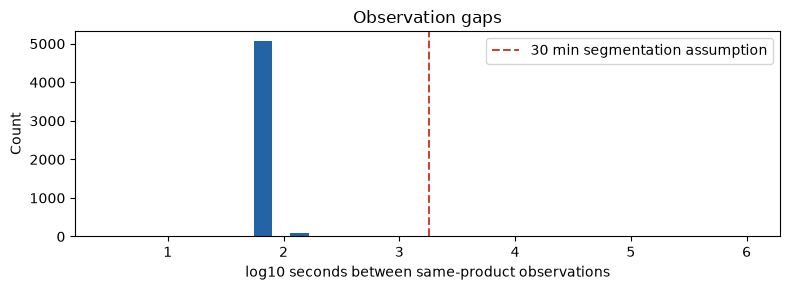

In [2]:
raw_n = len(raw)
df=raw.drop_duplicates().copy()
assert not df._id.duplicated().any()
df=df.loc[df.EQUIP_CD.eq('S14') & df.PART_NAME.str.startswith(('CN7','RG3'))].copy()
df['time']=pd.to_datetime(df.TimeStamp)
df['defect']=df.PassOrFail.map({'Y':0,'N':1}).astype(int)
df=df.sort_values(['time','_id']).reset_index(drop=True)
GROUP=['EQUIP_CD','PART_NAME']
g=df.groupby(GROUP,sort=False)
df['gap_seconds']=g.time.diff().dt.total_seconds()
date=df.time.dt.date
previous_date=g.time.shift().dt.date
new_segment=(df.gap_seconds.isna() | df.gap_seconds.gt(1800) | date.ne(previous_date)
    | df.PART_FACT_PLAN_DATE.ne(g.PART_FACT_PLAN_DATE.shift())
    | df.PART_FACT_SERIAL.ne(g.PART_FACT_SERIAL.shift()))
segment_number=new_segment.groupby([df.EQUIP_CD,df.PART_NAME],sort=False).cumsum()
df['segment']=pd.factorize(pd.MultiIndex.from_arrays([df.EQUIP_CD,df.PART_NAME,segment_number]))[0]
assert df.groupby('segment').PART_NAME.nunique().max()==1
assert df.groupby('segment').EQUIP_CD.nunique().max()==1
print('원본/분석 행:',raw_n,len(df),'불량:',int(df.defect.sum()),'이력 구간:',df.segment.nunique())
display(df.gap_seconds.describe(percentiles=[.5,.9,.95,.99]).to_frame())
print('동일 제품의 30분 초과 공백:',int(df.gap_seconds.gt(1800).sum()))
daily=df.groupby([df.time.dt.date,'PART_NAME']).defect.agg(['count','sum'])
display(daily)
numeric=list(raw.columns[raw.columns.get_loc('Injection_Time'):])
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in numeric)
assert 'Reason' not in numeric
fig,ax=plt.subplots(figsize=(8,3))
gap=df.gap_seconds.dropna()
ax.hist(np.log10(gap),bins=35,color='#2463a6')
ax.axvline(np.log10(1800),color='#c44835',linestyle='--',label='30 min segmentation assumption')
ax.set(xlabel='log10 seconds between same-product observations',ylabel='Count',title='Observation gaps')
ax.legend(); fig.tight_layout(); plt.show()

## 2. 과거만 사용하는 시계열 변수

각 수치 변수에서 현재값-직전값, **현재 건을 제외한** 직전 5·10건 평균과 표준편차를 생성한다. `shift(1)` 후 rolling을 적용한다. 평균은 최소 1개, 표준편차는 최소 2개의 과거 관측을 요구하고 부족하면 결측으로 남긴다. 5·10건의 가용 이력 개수도 입력한다. 구간 첫 기록은 과거가 없고, 학습 구간에서만 맞춘 결측 대체를 사용한다.

현재 공정값은 사이클 종료 후 얻을 수 있다는 기존 가정이다. 실제 불량 라벨은 어떤 과거 특성에도 사용하지 않는다. 평가 중 이전 시각의 공정값은 사용할 수 있다는 순차 추론 시나리오다. 평가 라벨로 재학습하지 않는다.

In [3]:
def make_history(frame):
    hist=pd.DataFrame(index=frame.index)
    for c in numeric:
        groups=frame.groupby('segment',sort=False)[c]
        hist[c+'__delta1']=frame[c]-groups.shift(1)
        for w in (5,10):
            hist[c+f'__past{w}_mean']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=1).mean())
            hist[c+f'__past{w}_std']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=2).std())
    previous_count=frame.groupby('segment',sort=False).cumcount()
    for w in (5,10): hist[f'history_count_{w}']=previous_count.clip(upper=w)
    return hist
hist=make_history(df)
extended=pd.concat([df,hist],axis=1)
assert df.groupby('segment').time.diff().dropna().gt(pd.Timedelta(0)).all()
first=df.groupby('segment').head(1).index
assert hist.loc[first,[c for c in hist if not c.startswith('history_count')]].isna().all().all()
# 독립 확인: 한 개 창의 평균을 원래 과거 기록에서 직접 재계산한다.
segment=df.segment.value_counts().idxmax()
idx=df.index[df.segment.eq(segment)][10]
previous=df.loc[(df.segment.eq(segment)) & (df.time < df.loc[idx,'time'])].tail(5)
assert np.isclose(hist.loc[idx,'Injection_Time__past5_mean'],previous.Injection_Time.mean())
# 미래 센서값을 바꿔도 이전 시점의 이력 특성이 변하지 않는지 확인한다.
cut=df.time.quantile(.6)
changed=df.copy()
changed.loc[changed.time>cut,numeric]=changed.loc[changed.time>cut,numeric]*1.1+17
changed_hist=make_history(changed)
pd.testing.assert_frame_equal(hist.loc[df.time<=cut],changed_hist.loc[df.time<=cut])
display(hist[['history_count_5','history_count_10']].describe())
display(extended[['time','PART_NAME','Injection_Time','Injection_Time__delta1',
                  'Injection_Time__past5_mean','history_count_5']].head(12))
print('이력 없는 기록 비율:',float(hist.history_count_5.eq(0).mean()))
print('미래 값 변경 불변성, 구간 경계, 과거 평균 직접 계산 확인 완료')

<local-runtime>/cell.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist[c+'__delta1']=frame[c]-groups.shift(1)
<local-runtime>/cell.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist[c+f'__past{w}_mean']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=1).mean())
<local-runtime>/cell.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To g

<local-runtime>/cell.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for w in (5,10): hist[f'history_count_{w}']=previous_count.clip(upper=w)


<local-runtime>/cell.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist[c+'__delta1']=frame[c]-groups.shift(1)
<local-runtime>/cell.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist[c+f'__past{w}_mean']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=1).mean())
<local-runtime>/cell.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To g

<local-runtime>/cell.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for w in (5,10): hist[f'history_count_{w}']=previous_count.clip(upper=w)


,history_count_5,history_count_10
count,5230.000000,5230.000000
mean,4.911090,9.678776
std,0.567437,1.470715
min,0.000000,0.000000
25%,5.000000,10.000000
50%,5.000000,10.000000
75%,5.000000,10.000000
max,5.000000,10.000000


,time,PART_NAME,Injection_Time,Injection_Time__delta1,Injection_Time__past5_mean,history_count_5
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,9.59,NaN,NaN,0
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,9.60,0.010000,9.590000,1
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,9.60,NaN,NaN,0
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,9.59,-0.010000,9.600000,1
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,9.59,-0.010000,9.595000,2
5,2020-10-16 05:00:46,CN7 W/S SIDE MLD'G RH,9.58,-0.010000,9.593334,3
6,2020-10-16 05:00:46,CN7 W/S SIDE MLD'G LH,9.58,-0.010000,9.595000,2
7,2020-10-16 05:01:46,CN7 W/S SIDE MLD'G RH,9.58,0.000000,9.590000,4
8,2020-10-16 05:01:46,CN7 W/S SIDE MLD'G LH,9.58,0.000000,9.590000,3
9,2020-10-16 05:02:46,CN7 W/S SIDE MLD'G RH,9.57,-0.010000,9.588000,5


이력 없는 기록 비율: 0.006309751434034417
미래 값 변경 불변성, 구간 경계, 과거 평균 직접 계산 확인 완료


## 3. 시간순 반복 비교 설계

세 번의 확장 학습 구간을 사용한다. 각 fold에서 **학습 → 임계값 조정 → 평가**를 분리한다. 평가 날짜는 fold 사이에 겹치지 않는다. 이후 fold의 학습이 이전 fold의 데이터를 포함하는 것은 과거 데이터가 축적되는 상황이다.

| fold | 학습 끝(미포함) | 임계값 조정 끝(미포함) | 평가 끝(미포함) |
|---|---|---|---|
| F1 | 10월 22일 | 10월 23일 | 10월 24일 |
| F2 | 10월 23일 | 10월 27일 | 10월 28일 |
| F3 | 10월 27일 | 11월 1일 | 11월 7일 |

연도는 모두 2020년이다. 이 날짜들은 데이터 기간·불량 존재를 확인해 정한 탐색 설계이고 새로운 미사용 검증 기간이 아니다. F3는 기존 분석의 날짜 경계와 같다.

같은 날짜·생산 지시 묶음·이력 구간이 fold 내 분리를 넘지 않는지 확인한다. 제품별 라벨 구성도 함께 표시한다. 일부 제품 불량이 학습/조정에 없을 수 있으며 이 문제를 재분리로 숨기지 않는다.

고정한 RF 설정: 트리 200, 깊이 6, 최소 leaf 5, balanced_subsample, seed 42. 두 방식 모두 같은 설정, 같은 기록에서 비교한다. 각 모델의 임계값은 해당 조정 구간에서 검사 비율 10% 이내, TP 최대, FP 최소 순으로 선택한다. 미래의 검사 비율까지 보장하는 제약은 아니다.

In [4]:
from sklearn.base import clone
folds=[('F1','2020-10-22','2020-10-23','2020-10-24'),
       ('F2','2020-10-23','2020-10-27','2020-10-28'),
       ('F3','2020-10-27','2020-11-01','2020-11-07')]
def masks(a,b,c):
    t=extended.time
    return t.lt(a),t.ge(a)&t.lt(b),t.ge(b)&t.lt(c)
def group_keys(x):
    return set(x[['PART_FACT_PLAN_DATE','PART_FACT_SERIAL','EQUIP_CD']].astype(str).agg('|'.join,axis=1))
split_rows=[]; composition=[]; seen=set()
for name,a,b,c in folds:
    sections=dict(zip(['train','tune','evaluate'],masks(a,b,c)))
    frames={k:extended.loc[m] for k,m in sections.items()}
    for k,x in frames.items():
        assert x.defect.nunique()==2
        split_rows.append({'fold':name,'split':k,'rows':len(x),'defects':int(x.defect.sum())})
        for part,z in x.groupby('PART_NAME'):
            composition.append({'fold':name,'split':k,'part':part,'rows':len(z),'defects':int(z.defect.sum())})
    for left,right in [('train','tune'),('train','evaluate'),('tune','evaluate')]:
        assert group_keys(frames[left]).isdisjoint(group_keys(frames[right]))
        assert set(frames[left].segment).isdisjoint(frames[right].segment)
        assert frames[left].time.max()<frames[right].time.min()
    ids=set(frames['evaluate']._id)
    assert ids.isdisjoint(seen); seen.update(ids)
split_table=pd.DataFrame(split_rows)
display(split_table)
display(pd.DataFrame(composition))
def model_pipeline(cols):
    pre=ColumnTransformer([
      ('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),cols),
      ('part',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['PART_NAME'])])
    return Pipeline([('preprocess',pre),('model',RandomForestClassifier(n_estimators=200,max_depth=6,
             min_samples_leaf=5,class_weight='balanced_subsample',random_state=42,n_jobs=2))])
def count_metrics(y,s,t):
    tn,fp,fn,tp=confusion_matrix(y,np.asarray(s)>=t,labels=[0,1]).ravel()
    return dict(TP=int(tp),FN=int(fn),FP=int(fp),TN=int(tn),inspections=int(tp+fp),
        inspection_rate=float((tp+fp)/len(y)),recall=float(tp/(tp+fn)),
        precision=float(tp/(tp+fp)) if tp+fp else 0.)
def choose(y,s):
    thresholds=np.r_[np.nextafter(max(s),np.inf),np.unique(s)]
    rows=pd.DataFrame([{'threshold':t,**count_metrics(y,s,t)} for t in thresholds])
    selected=rows.loc[rows.inspection_rate<=.10].sort_values(['TP','FP','threshold'],ascending=[False,True,False]).iloc[0]
    return float(selected.threshold)
print('설계 고정 완료. 평가 점수에 따른 하이퍼파라미터 탐색 없음.')

,fold,split,rows,defects
0,F1,train,1293,17
1,F1,tune,600,15
2,F1,evaluate,500,10
3,F2,train,1893,32
4,F2,tune,500,10
5,F2,evaluate,628,10
6,F3,train,2393,42
7,F3,tune,1837,10
8,F3,evaluate,1000,8


,fold,split,part,rows,defects
0,F1,train,CN7 W/S SIDE MLD'G LH,605,4
1,F1,train,CN7 W/S SIDE MLD'G RH,606,13
2,F1,train,"RG3 MOLD'G W/SHLD, LH",41,0
3,F1,train,"RG3 MOLD'G W/SHLD, RH",41,0
4,F1,tune,"RG3 MOLD'G W/SHLD, LH",300,0
5,F1,tune,"RG3 MOLD'G W/SHLD, RH",300,15
6,F1,evaluate,"RG3 MOLD'G W/SHLD, LH",250,0
7,F1,evaluate,"RG3 MOLD'G W/SHLD, RH",250,10
8,F2,train,CN7 W/S SIDE MLD'G LH,605,4
9,F2,train,CN7 W/S SIDE MLD'G RH,606,13


설계 고정 완료. 평가 점수에 따른 하이퍼파라미터 탐색 없음.


## 4. 현재 값과 시계열 추가 값 비교

상수/모두 결측인 입력은 각 fold의 학습 구간에서만 판단해 제외한다. 과거 정보가 없어도 평가 행을 삭제하지 않는다. 양 방식에 동일한 관측 건을 유지한다. 동일 환경에서 재실행한 baseline과 비교하며, 사용자의 이전 코랩 수치와 섞어 증감 계산하지 않는다.

F1 current_only: AP=0.0200, TP=0, FN=10, FP=0


F1 with_history: AP=0.0456, TP=4, FN=6, FP=148


F2 current_only: AP=0.0144, TP=0, FN=10, FP=0


F2 with_history: AP=0.0430, TP=0, FN=10, FP=4


F3 current_only: AP=0.1039, TP=2, FN=6, FP=35


F3 with_history: AP=0.0230, TP=2, FN=6, FP=58


,fold,variant,features,threshold,tune_AP,tune_inspection_rate,evaluation_AP,TP,FN,FP,TN,inspections,inspection_rate,recall,precision
0,F1,current_only,25,0.004920,0.024231,0.000000,0.020000,0,10,0,490,0,0.000000,0.00,0.000000
1,F1,with_history,144,0.009512,0.030010,0.093333,0.045609,4,6,148,342,152,0.304000,0.40,0.026316
2,F2,current_only,26,0.489378,0.067380,0.006000,0.014411,0,10,0,618,0,0.000000,0.00,0.000000
3,F2,with_history,150,0.260719,0.044169,0.052000,0.043040,0,10,4,614,4,0.006369,0.00,0.000000
4,F3,current_only,26,0.118960,0.180517,0.047904,0.103929,2,6,35,957,37,0.037000,0.25,0.054054
5,F3,with_history,150,0.183238,0.075040,0.066957,0.023044,2,6,58,934,60,0.060000,0.25,0.033333


,TP,FN,FP,TN,inspections,recall,inspection_rate
variant,,,,,,,
current_only,2,26,35,2065,37,0.071429,0.017387
with_history,6,22,210,1890,216,0.214286,0.101504


합산 건수는 겹치지 않는 평가 구간 기준. fold는 공통 학습 이력이 있어 독립 실험이 아닙니다.
다른 모델의 점수를 합쳐 AP를 계산하지 않습니다. AP는 fold별로 비교합니다.


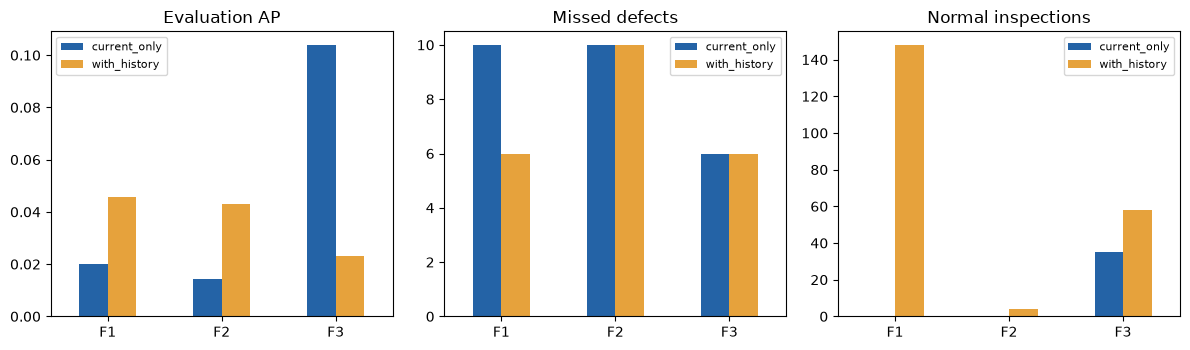

outcome                                  FN  FP   TN  TP
fold variant      PART_NAME                             
F1   current_only RG3 MOLD'G W/SHLD, LH   0   0  250   0
                  RG3 MOLD'G W/SHLD, RH  10   0  240   0
     with_history RG3 MOLD'G W/SHLD, LH   0  76  174   0
                  RG3 MOLD'G W/SHLD, RH   6  72  168   4
F2   current_only CN7 W/S SIDE MLD'G LH   5   0  309   0
                  CN7 W/S SIDE MLD'G RH   5   0  309   0
     with_history CN7 W/S SIDE MLD'G LH   5   2  307   0
                  CN7 W/S SIDE MLD'G RH   5   2  307   0
F3   current_only CN7 W/S SIDE MLD'G LH   1   0  462   0
                  CN7 W/S SIDE MLD'G RH   0   0  463   0
                  RG3 MOLD'G W/SHLD, LH   5   0   32   0
                  RG3 MOLD'G W/SHLD, RH   0  35    0   2
     with_history CN7 W/S SIDE MLD'G LH   1  15  447   0
                  CN7 W/S SIDE MLD'G RH   0  17  446   0
                  RG3 MOLD'G W/SHLD, LH   5   0   32   0
                  RG3 MOLD'G W/SHLD, RH   0  26    9   2

In [5]:
results=[]; predictions=[]; trained={}
for fold,a,b,c in folds:
    mt,mv,me=masks(a,b,c)
    tr,va,te=[extended.loc[m] for m in (mt,mv,me)]
    for variant,candidates in [('current_only',numeric),('with_history',numeric+list(hist.columns))]:
        cols=[c for c in candidates if tr[c].nunique(dropna=True)>1]
        model=model_pipeline(cols)
        use=cols+['PART_NAME']
        model.fit(tr[use],tr.defect)
        vs=model.predict_proba(va[use])[:,1]
        threshold=choose(va.defect,vs)
        es=model.predict_proba(te[use])[:,1]
        row={'fold':fold,'variant':variant,'features':len(cols)+1,'threshold':threshold,
             'tune_AP':float(average_precision_score(va.defect,vs)),
             'tune_inspection_rate':count_metrics(va.defect,vs,threshold)['inspection_rate'],
             'evaluation_AP':float(average_precision_score(te.defect,es)),
             **count_metrics(te.defect,es,threshold)}
        results.append(row)
        pred=te[['_id','time','PART_NAME','defect','Reason']].copy()
        pred['fold']=fold; pred['variant']=variant; pred['score']=es
        pred['pred']=(es>=threshold).astype(int)
        pred['outcome']=np.select([pred.defect.eq(1)&pred.pred.eq(1),pred.defect.eq(1)&pred.pred.eq(0),
                                  pred.defect.eq(0)&pred.pred.eq(1)],['TP','FN','FP'],default='TN')
        predictions.append(pred)
        trained[(fold,variant)]=(model,use)
        print(f'{fold} {variant}: AP={row["evaluation_AP"]:.4f}, TP={row["TP"]}, FN={row["FN"]}, FP={row["FP"]}')
result=pd.DataFrame(results)
predictions=pd.concat(predictions,ignore_index=True)
display(result)
assert all(result.TP+result.FN==np.repeat([10,10,8],2))
aggregate=result.groupby('variant')[['TP','FN','FP','TN','inspections']].sum()
aggregate['recall']=aggregate.TP/(aggregate.TP+aggregate.FN)
aggregate['inspection_rate']=aggregate.inspections/aggregate[['TP','FN','FP','TN']].sum(axis=1)
display(aggregate)
print('합산 건수는 겹치지 않는 평가 구간 기준. fold는 공통 학습 이력이 있어 독립 실험이 아닙니다.')
print('다른 모델의 점수를 합쳐 AP를 계산하지 않습니다. AP는 fold별로 비교합니다.')
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
for ax,metric,title in zip(axes,['evaluation_AP','FN','FP'],['Evaluation AP','Missed defects','Normal inspections']):
    result.pivot(index='fold',columns='variant',values=metric).plot.bar(ax=ax,color=['#2463a6','#e6a23c'],rot=0)
    ax.set_title(title); ax.set_xlabel(''); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
part_result=predictions.groupby(['fold','variant','PART_NAME','outcome']).size().unstack(fill_value=0)
display(part_result)

## 5. 기존 미탐과 같은 기간 양품 비교

사용자가 보고한 기존 코랩 미탐 중 RG3 LH 5건은 11월 4일 기록이다. 같은 최종 평가 기간의 RG3 LH 양품 32건과 비교한다. 이 다섯 건은 이 제품의 평가 불량 전부이므로 새 모델에 따라 사례를 다시 고르지 않는다.

학습 양품의 중앙값만 기준으로 보면 공정 전체의 변화도 불량 특성처럼 보일 수 있다. 같은 평가 기간 양품의 분포를 함께 본다. 작은 표본이고 제품/날짜에 군집되어 있어 통계적 유의성이나 인과관계는 주장하지 않는다. 비교 결과로 임계값을 다시 맞추지 않는다.

,feature,defect,n,minimum,q25,median,q75,maximum
0,Cushion_Position,0,32,654.210022,654.219971,654.239990,654.252502,654.270020
1,Cushion_Position,1,5,654.219971,654.239990,654.239990,654.250000,654.260010
2,Plasticizing_Time,0,32,12.940000,13.090000,13.130000,13.150000,13.190000
3,Plasticizing_Time,1,5,13.130000,13.130000,13.140000,13.150000,13.170000
4,Average_Back_Pressure,0,32,60.599998,61.975000,62.200001,62.500000,62.900002
5,Average_Back_Pressure,1,5,61.900002,62.099998,62.200001,62.400002,62.400002


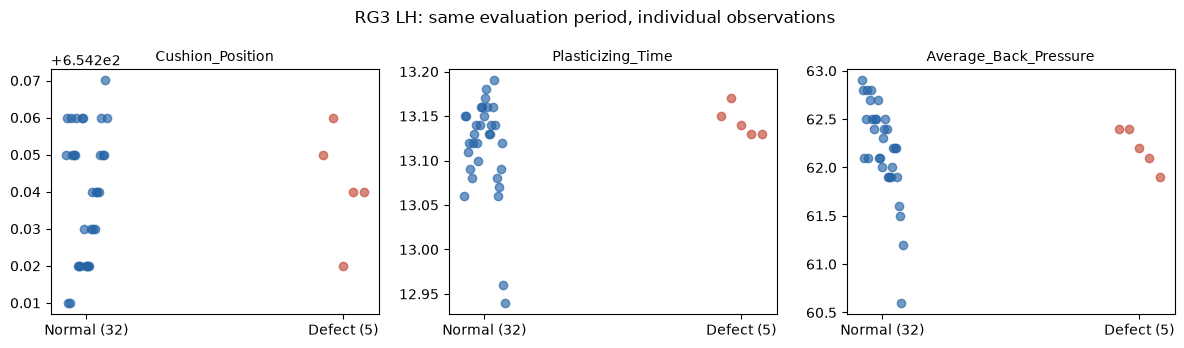

outcome,FN,TN
variant,,
current_only,5,32
with_history,5,32


,Cushion_Position__delta1,Plasticizing_Time__delta1,Average_Back_Pressure__delta1,Cushion_Position__past5_mean,Plasticizing_Time__past5_mean,Average_Back_Pressure__past5_mean
defect,,,,,,
0,0.0,0.01,0.000000,654.236011,13.126,62.260001
1,0.0,0.00,-0.199997,654.235986,13.144,62.420000


동일 기간 비교도 공정 원인 규명이나 허용 규격 판정이 아닙니다.


In [6]:
case=extended.loc[extended.time.ge('2020-11-01') & extended.PART_NAME.eq("RG3 MOLD'G W/SHLD, LH")].copy()
assert case.defect.value_counts().to_dict()=={0:32,1:5}
variables=['Cushion_Position','Plasticizing_Time','Average_Back_Pressure']
stats=[]
for feature in variables:
    for label,x in case.groupby('defect'):
        q=x[feature].quantile([0,.25,.5,.75,1])
        stats.append(dict(feature=feature,defect=int(label),n=len(x),minimum=q[0],q25=q[.25],
                          median=q[.5],q75=q[.75],maximum=q[1]))
case_stats=pd.DataFrame(stats)
display(case_stats)
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,feature in zip(axes,variables):
    for label,color in [(0,'#2463a6'),(1,'#c44835')]:
        values=case.loc[case.defect.eq(label),feature].to_numpy()
        ax.scatter(label+np.linspace(-.08,.08,len(values)),values,color=color,alpha=.65)
    ax.set_xticks([0,1],['Normal (32)','Defect (5)']); ax.set_title(feature,fontsize=10)
fig.suptitle('RG3 LH: same evaluation period, individual observations')
fig.tight_layout(); plt.show()
display(predictions.loc[predictions.fold.eq('F3') & predictions.PART_NAME.eq("RG3 MOLD'G W/SHLD, LH")]
        .groupby(['variant','outcome']).size().unstack(fill_value=0))
history_comparison=case.groupby('defect')[[c+'__delta1' for c in variables]+[c+'__past5_mean' for c in variables]].median()
display(history_comparison)
print('동일 기간 비교도 공정 원인 규명이나 허용 규격 판정이 아닙니다.')

## 저장된 추가 실험의 결론

**현재 설정의 시계열 추가 모델은 일관된 개선으로 채택하지 않는다.**

- F1: TP 0→4로 늘었지만 FP 0→148. 조정 시 검사 비율 9.33%가 평가에서는 30.4%로 증가했다. 10% 상한은 조정 구간에서만 적용된 것이며 미래 검사량은 보장하지 못했다.
- F2: AP는 0.0144→0.0430으로 높아졌지만 TP는 0건 그대로였고 FP가 4건 늘었다.
- F3: TP 2건/FN 6건은 그대로인데 FP 35→58, AP 0.1039→0.0230으로 나빠졌다.
- 합산: 불량 4건을 더 탐지하는 대신 정상 추가 검사 175건이 늘었다. 합산만으로 개선을 주장하지 않는다.

RG3 LH 미탐 5건은 쿠션 위치·가소화 시간·평균 배압 모두 같은 기간 양품 32건의 범위 안에 있었다. 쿠션 위치와 평균 배압 중앙값은 양품/불량이 같고 가소화 시간도 13.130/13.140으로 가까웠다. 학습 양품 대비 변화가 있다고 해서 불량 고유의 원인으로 해석할 수 없었다. 이것이 모든 다변량 구분 가능성을 부정하는 것은 아니다.

이 결론은 저장된 로컬 실행에 해당한다. 다른 환경에서 실행하면 출력에 맞춰 갱신한다. 사용자의 기존 코랩 결과는 README에서 별도로 기록했으며, 이번 비교의 baseline과 혼합하지 않았다. 다음 개선은 제품별 불량 라벨과 새로운 기간의 검증을 우선한다. 이번 실험에서 추가 튜닝은 하지 않았다.


## 6. 해석과 재현 정보

- AP가 올라도 실제 판정 기준의 TP/FN/FP를 함께 확인한다. 평균 지표만으로 성공을 선언하지 않는다.
- 기록 단위 창(5·10건)은 시간 길이가 일정하지 않으며 누락된 생산 기록을 복구하지 못한다.
- 제품에 따라 학습 불량이 없고, fold별 제품 구성이 달라진다. 특히 RG3 LH 불량은 11월 평가에만 있다.
- 데이터는 약 5천 건, 한 설비다. 시계열 특성 설계와 ML 검증 경험이며 운영 시스템/빅데이터 처리/딥러닝 네트워크 개발은 아니다.
- 과거 평가 결과를 알고 시작한 후속 실험이다. 선택 편향이 남으며 이후 기간의 새로운 데이터 검증이 필요하다.
- 원본 CSV/가이드북을 배포 파일에 포함하지 않는다. 버전과 원본 해시를 기록한다.

**출처:** 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 사출성형기 AI 데이터셋, KAIST(울산과학기술원, ㈜이피엠솔루션즈), 2020.12.14., https://www.kamp-ai.kr/

제공 가이드북은 연구/공식 활용 시 출처 표기와 활용 내용·문서의 이메일 안내(kamp@kaist.ac.kr)를 포함한다. 이메일을 발송하지 않았다.

In [7]:
import importlib.metadata as metadata
versions={k:metadata.version(k) for k in ['pandas','numpy','scikit-learn','matplotlib']}
print('실행 버전:',versions)
summary={'source_sha256':source_sha256,'versions':versions,'splits':split_table.to_dict('records'),
         'results':result.to_dict('records'),'aggregate':aggregate.reset_index().to_dict('records'),
         'case_stats':case_stats.to_dict('records'),'segments':int(df.segment.nunique())}
if os.environ.get('MOLDING_RESULT_DIR'):
    out=Path(os.environ['MOLDING_RESULT_DIR']); out.mkdir(parents=True,exist_ok=True)
    (out/'timeseries_summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    predictions.to_csv(out/'timeseries_predictions.csv',index=False)
print('시계열 비교 완료. 개선 여부는 결과 표 그대로 판단합니다.')

실행 버전: {'pandas': '3.0.5', 'numpy': '2.5.3', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1'}
시계열 비교 완료. 개선 여부는 결과 표 그대로 판단합니다.
